<a href="https://colab.research.google.com/github/Anwesha-code/PBL_Project/blob/main/dprnnNinOA3_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# CELL 1: Setup Google Drive and Initialize
import tensorflow as tf      #used to build neural networks
import os
from google.colab import drive

print("Mounting Google Drive...")
drive.mount('/content/drive')
print("Google Drive mounted successfully\n")

gdrive_checkpoint_dir = '/content/drive/MyDrive/ninja_oa_checkpoints'         #Any files saved to this path will persist even after the Colab session ends

checkpoints = sorted([f for f in os.listdir(gdrive_checkpoint_dir)
                      if f.endswith('.pkl') and 'iter_' in f and 'iteration' in f])    #checks in directory for files that end in .pkl, contain iter_ , and iteration in name
if checkpoints:
    iterations = [int(f.split('iter_')[1].split('_')[0]) for f in checkpoints]         #finds last completed iteration and resume from there
    resume_from_iteration = max(iterations)
    print(f"✓ Found last completed checkpoint: iter {resume_from_iteration}")
else:
    resume_from_iteration = None
    print("No checkpoints found, will start from scratch.")

Mounting Google Drive...
Mounted at /content/drive
Google Drive mounted successfully

✓ Found last completed checkpoint: iter 11


In [ ]:
# CELL 2: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from datetime import datetime
from typing import Dict, List, Tuple, Callable         #help in code documentation
from scipy import stats
import pickle                 #Serialises Python objects to files; for checkpoint saving
import os
import shutil                   # high level file operations, like copying, moving

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, LSTM, Bidirectional, Dropout,
    BatchNormalization, GlobalMaxPooling1D, Dense
)                                                                    #TensorFlow/Keras components; Building blocks of LSTM NN architecture
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)                              #Sets random seeds for reproducibility; Without seeds, neural network initialisation and optimisation would produce different results each run

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")


All libraries imported successfully!
TensorFlow version: 2.19.0
NumPy version: 2.0.2
Pandas version: 2.2.2


In [ ]:
# CELL 3: Load Dataset
from google.colab import files

print("\nUpload your dataset file...")
uploaded = files.upload()

print("Loading carbon emission dataset...")
df = pd.read_excel('data_center_carbon_emission_dataset_COPY.xlsx')

print(f"Dataset loaded successfully! Shape: {df.shape}")
print(f"\nDataset Info:")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nColumn names:")
print(df.columns.tolist())



Upload your dataset file...


Saving data_center_carbon_emission_dataset_COPY.xlsx to data_center_carbon_emission_dataset_COPY.xlsx
Loading carbon emission dataset...
Dataset loaded successfully! Shape: (75000, 18)

Dataset Info:
Rows: 75,000
Columns: 18

First few rows:
                 MAC  weekday           timestamp  voltage  current  power  \
0  6F:64:08:15:99:33        5 2025-08-23 00:00:00   120.75    0.110  10.75   
1  5E:63:07:14:98:32        5 2025-08-23 00:00:30   119.79    0.037   5.01   
2  4D:62:06:13:97:31        5 2025-08-23 00:01:00   120.97    0.106  11.98   
3  4D:62:06:13:97:31        5 2025-08-23 00:01:30   122.28    0.055   5.56   
4  5E:63:07:14:98:32        5 2025-08-23 00:02:00   119.65    0.117  13.48   

   frequency  energy  power_factor  esp32_temperature  cpu_temperature  \
0       59.9   0.090          1.00              21.98             43.5   
1       60.0   0.131          0.86              23.02             38.8   
2       59.8   0.231          0.98              23.11             5

In [ ]:
# CELL 4: Data Preprocessing
print("Starting data preprocessing...\n")

df['timestamp'] = pd.to_datetime(df['timestamp'])       #engineering features
df = df.sort_values('timestamp').reset_index(drop=True)            #arrange rows chronologically
print("Converted timestamp and sorted data")

df.ffill(inplace=True)                                           #forward fill
print("Missing values forward filled")

original_len = len(df)
df.drop_duplicates(inplace=True)                        #drop duplicates if any
print(f"Removed {original_len - len(df)} duplicate rows")

df['hour'] = df['timestamp'].dt.hour                       #extract temporal features
df['dayofweek'] = df['timestamp'].dt.dayofweek
print("Created time-based features: hour, dayofweek")

original_len = len(df)                                #selects numerical colums; compute z scores
z_scores = np.abs(stats.zscore(df.select_dtypes(include=[np.number])))
df = df[(z_scores < 3).all(axis=1)]                                              #Check if |z|< 3; keep all features with |z|<3; REMOVES OUTLIERS
print(f"Removed {original_len - len(df)} outlier rows")

df['voltage_lag1'] = df['voltage'].shift(1)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print("Created lag features and dropped NaNs")

print(f"\nFinal dataset shape after preprocessing: {df.shape}")


Starting data preprocessing...

Converted timestamp and sorted data
Missing values forward filled
Removed 0 duplicate rows
Created time-based features: hour, dayofweek
Removed 769 outlier rows
Created lag features and dropped NaNs

Final dataset shape after preprocessing: (74230, 21)


In [ ]:
# CELL 5: Train-Validation-Test Split (BEFORE Scaling)
print("Splitting dataset into Train (70%), Validation (15%), Test (15%)\n")

train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)

train = df[:train_size].copy()
val = df[train_size:train_size + val_size].copy()
test = df[train_size + val_size:].copy()

print(f"Train shape: {train.shape} ({train.shape[0]:,} samples)")
print(f"Validation shape: {val.shape} ({val.shape[0]:,} samples)")
print(f"Test shape: {test.shape} ({test.shape[0]:,} samples)")


Splitting dataset into Train (70%), Validation (15%), Test (15%)

Train shape: (51961, 21) (51,961 samples)
Validation shape: (11134, 21) (11,134 samples)
Test shape: (11135, 21) (11,135 samples)


In [ ]:
# CELL 6: Feature Scaling and Encoding (FIT ON ALL DATA)
print("\nScaling numerical features\n")

num_cols = [
    'voltage', 'current', 'power', 'frequency', 'energy', 'power_factor',
    'esp32_temperature', 'cpu_temperature', 'gpu_temperature',
    'cpu_usage_percent', 'cpu_power_watts', 'gpu_usage_percent',
    'gpu_power_watts', 'ram_usage_percent', 'ram_power_watts'
]

# Fit scaler on ALL data combined (recommended for time series)
all_data_temp = pd.concat([train, val, test], ignore_index=True)            #numerical features-> scaling; categorical features->encoding
scaler = StandardScaler()                            #calculates z score
all_data_temp[num_cols] = scaler.fit_transform(all_data_temp[num_cols])                  #calculates mean/std and transforms in one step; mean≈0, std≈1
#Prevents features with large ranges from dominating; Accelerates neural network convergence; Improves numerical stability


# Apply same scaler to train/val/test
train[num_cols] = scaler.transform(train[num_cols])              #Applies the fitted scaler to each split; uses same transformation parameters across splits
val[num_cols] = scaler.transform(val[num_cols])
test[num_cols] = scaler.transform(test[num_cols])

print("Numerical features scaled (scaler fit on all data)")

# One-hot encode categorical variables SEPARATELY
train = pd.get_dummies(train, columns=['MAC', 'weekday'], drop_first=True)
val = pd.get_dummies(val, columns=['MAC', 'weekday'], drop_first=True)
test = pd.get_dummies(test, columns=['MAC', 'weekday'], drop_first=True)

# Align columns; Ensures all splits have identical columns in same order
all_train_cols = set(train.columns)
all_val_cols = set(val.columns)
all_test_cols = set(test.columns)
all_cols = all_train_cols.union(all_val_cols).union(all_test_cols)

for col in all_cols:
    if col not in train.columns:
        train[col] = 0
    if col not in val.columns:
        val[col] = 0
    if col not in test.columns:
        test[col] = 0

train = train[sorted(train.columns)]
val = val[sorted(val.columns)]
test = test[sorted(test.columns)]

print("One-hot encoded and aligned columns")

# Final verification
print(f"\nFinal Verification - Energy column:")
print(f"  Train - Mean: {train['energy'].mean():.4f}, Std: {train['energy'].std():.4f}, Min: {train['energy'].min():.4f}, Max: {train['energy'].max():.4f}")
print(f"  Val   - Mean: {val['energy'].mean():.4f}, Std: {val['energy'].std():.4f}, Min: {val['energy'].min():.4f}, Max: {val['energy'].max():.4f}")
print(f"  Test  - Mean: {test['energy'].mean():.4f}, Std: {test['energy'].std():.4f}, Min: {test['energy'].min():.4f}, Max: {test['energy'].max():.4f}")

print(f"\nFinal preprocessed dataset shapes:")
print(f"Train: {train.shape}, Val: {val.shape}, Test: {test.shape}")



Scaling numerical features

Numerical features scaled (scaler fit on all data)
One-hot encoded and aligned columns

Final Verification - Energy column:
  Train - Mean: -0.5205, Std: 0.6979, Min: -1.7283, Max: 0.6939
  Val   - Mean: 0.9548, Std: 0.1501, Min: 0.6939, Max: 1.2142
  Test  - Mean: 1.4740, Std: 0.1499, Min: 1.2142, Max: 1.7338

Final preprocessed dataset shapes:
Train: (51961, 28), Val: (11134, 28), Test: (11135, 28)


In [ ]:
# CELL 7: Create Sequences for RNN
print("Preparing sequences for recurrent neural network...\n")
#Transforms tabular data into sequences suitable for recurrent neural networks
def create_sequences(data, target, seq_length):                    #creates sliding windows over the time series
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(target[i + seq_length])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

sequence_length = 10                           #timesteps of 10
target_col = 'energy'
feature_cols = [col for col in train.columns if col not in ['timestamp', target_col]]

X_train_arr = train[feature_cols].values
y_train_arr = train[target_col].values
X_val_arr = val[feature_cols].values
y_val_arr = val[target_col].values
X_test_arr = test[feature_cols].values
y_test_arr = test[target_col].values

X_train_seq, y_train_seq = create_sequences(X_train_arr, y_train_arr, sequence_length)                #Converts pandas DataFrames to NumPy arrays for faster numerical operations
X_val_seq, y_val_seq = create_sequences(X_val_arr, y_val_arr, sequence_length)
X_test_seq, y_test_seq = create_sequences(X_test_arr, y_test_arr, sequence_length)

print(f"Train sequence shape: {X_train_seq.shape}")
print(f"Validation sequence shape: {X_val_seq.shape}")
print(f"Test sequence shape: {X_test_seq.shape}")

seq_len = X_train_seq.shape[1]
num_feats = X_train_seq.shape[2]
print(f"\nEach sequence has {seq_len} time steps and {num_feats} features")


Preparing sequences for recurrent neural network...

Train sequence shape: (51951, 10, 26)
Validation sequence shape: (11124, 10, 26)
Test sequence shape: (11125, 10, 26)

Each sequence has 10 time steps and 26 features


In [ ]:
# CELL 8: Diagnostic Check
#Verifies that scaling was applied correctly
print("="*70)
print("SCALING VERIFICATION")
print("="*70)

print(f"\nTarget (energy) statistics:")
print(f"  Train - Min: {y_train_seq.min():.4f}, Max: {y_train_seq.max():.4f}, Mean: {y_train_seq.mean():.4f}, Std: {y_train_seq.std():.4f}")
print(f"  Val   - Min: {y_val_seq.min():.4f}, Max: {y_val_seq.max():.4f}, Mean: {y_val_seq.mean():.4f}, Std: {y_val_seq.std():.4f}")
print(f"  Test  - Min: {y_test_seq.min():.4f}, Max: {y_test_seq.max():.4f}, Mean: {y_test_seq.mean():.4f}, Std: {y_test_seq.std():.4f}")

print("\n" + "="*70)
print("Expected: All means near 0, all stds near 1")
print("="*70 + "\n")


SCALING VERIFICATION

Target (energy) statistics:
  Train - Min: -1.7279, Max: 0.6939, Mean: -0.5202, Std: 0.6978
  Val   - Min: 0.6945, Max: 1.2142, Mean: 0.9551, Std: 0.1500
  Test  - Min: 1.2146, Max: 1.7338, Mean: 1.4742, Std: 0.1498

Expected: All means near 0, all stds near 1



In [ ]:
# CELL 9: Ninja Optimization Algorithm
#Implements a custom meta-heuristic optimisation algorithm inspired by ninja stealth strategies
class NinjaOptimizationAlgorithm:
    def __init__(
        self,
        objective_function: Callable,                   #Function to minimise (validation loss)
        bounds: Dict[str, Tuple],                       #Hyperparameter search space
        n_agents: int = 12,                             #population size
        max_iterations: int = 12,                       #optimisation duration
        exploration_factor: float = 2.0,                #Controls exploration intensity
        exploitation_factor: float = 0.5,               #Controls exploitation intensity
        verbose: bool = True,
        checkpoint_dir: str = 'ninja_checkpoints',
        gdrive_backup_dir: str = None
    ):
        self.objective_function = objective_function
        self.bounds = bounds
        self.n_agents = n_agents
        self.max_iterations = max_iterations
        self.exploration_factor = exploration_factor
        self.exploitation_factor = exploitation_factor
        self.verbose = verbose
        self.checkpoint_dir = checkpoint_dir
        self.gdrive_backup_dir = gdrive_backup_dir

        if not os.path.exists(checkpoint_dir):
            os.makedirs(checkpoint_dir)

        self.param_names = list(bounds.keys())
        self.agents = self._initialize_population()               #initialise population
        self.fitness = np.full(n_agents, np.inf)                  #Creates fitness array (initialised to infinity), tracks each agent's performance

        self.best_agent = None
        self.best_fitness = np.inf
        self.convergence_curve = []
        self.start_time = None
        self.current_iteration = 0

    def _initialize_population(self) -> List[Dict]:                     #creates n agents random hypermeter configurations; i.e. agents left at n different diverse spots to start search from
        agents = []
        for _ in range(self.n_agents):
            agent = {}
            for param, bound in self.bounds.items():
                if bound[1] == 'int':
                    agent[param] = int(np.random.randint(bound[0][0], bound[0][1] + 1))
                elif bound[1] == 'float':
                    agent[param] = float(np.random.uniform(bound[0][0], bound[0][1]))
                elif bound[1] == 'float_log':
                    log_min = np.log10(bound[0][0])
                    log_max = np.log10(bound[0][1])
                    agent[param] = float(10 ** np.random.uniform(log_min, log_max))
                elif bound[1] == 'categorical':
                    selected_value = np.random.choice(bound[0])
                    if isinstance(selected_value, (np.integer, np.int64, np.int32)):
                        agent[param] = int(selected_value)
                    else:
                        agent[param] = selected_value
            agents.append(agent)
        return agents

    def _evaluate_fitness(self, agent: Dict) -> float:                         #fitness evaluation
        try:
            fitness = self.objective_function(agent)
            return fitness
        except Exception as e:
            if self.verbose:
                print(f"Evaluation failed: {e}")
            return np.inf

    def _exploration_phase(self, agent: Dict, iteration: int) -> Dict:                  #exploration phase
        new_agent = agent.copy()                                                  #Creates copy of agent
        progress = iteration / self.max_iterations                                #Calculates progress ratio (0 to 1);Progress ratio enables adaptive behaviour - exploration decreases as optimisation progresses.

        for param, bound in self.bounds.items():
            exploration_rate = self.exploration_factor * (1 - progress)                     #exploration facor=2.0

            if bound[1] == 'int':
                perturbation = np.random.randint(-int(exploration_rate), int(exploration_rate) + 1)
                new_value = agent[param] + perturbation
                new_agent[param] = int(np.clip(new_value, bound[0][0], bound[0][1]))

            elif bound[1] in ['float', 'float_log']:
                range_size = bound[0][1] - bound[0][0]
                perturbation = np.random.uniform(-exploration_rate, exploration_rate) * range_size * 0.1
                new_value = agent[param] + perturbation
                new_agent[param] = float(np.clip(new_value, bound[0][0], bound[0][1]))

            elif bound[1] == 'categorical':
                if np.random.rand() < exploration_rate * 0.3:
                    selected_value = np.random.choice(bound[0])
                    if isinstance(selected_value, (np.integer, np.int64, np.int32)):
                        new_agent[param] = int(selected_value)
                    else:
                        new_agent[param] = selected_value

        return new_agent
#Integer parameters jump between discrete values. Perturbation size decreases over time.


#Exploitation Phase
    def _exploitation_phase(self, agent: Dict, best_agent: Dict, iteration: int) -> Dict:
        new_agent = {}
        progress = iteration / self.max_iterations                             #Moves agent towards the currently best-known solution

        for param, bound in self.bounds.items():
            exploitation_rate = self.exploitation_factor * progress                      #exploitaation factor=0.5

            if bound[1] == 'int':
                direction = best_agent[param] - agent[param]
                step = int(direction * exploitation_rate)
                new_value = agent[param] + step
                new_agent[param] = int(np.clip(new_value, bound[0][0], bound[0][1]))

            elif bound[1] in ['float', 'float_log']:
                direction = best_agent[param] - agent[param]
                step = direction * exploitation_rate + np.random.normal(0, 0.01 * abs(direction))
                new_value = agent[param] + step
                new_agent[param] = float(np.clip(new_value, bound[0][0], bound[0][1]))

            elif bound[1] == 'categorical':
                if np.random.rand() < 0.7 + 0.3 * progress:
                    new_agent[param] = best_agent[param]
                else:
                    new_agent[param] = agent[param]

        return new_agent

    def _adaptive_phase_selection(self, iteration: int) -> str:
        progress = iteration / self.max_iterations
        exploitation_prob = 0.3 + 0.6 * progress

        if np.random.rand() < exploitation_prob and self.best_agent is not None:              #Probabilistically selects exploration vs. exploitation.
            return 'exploitation'
        else:
            return 'exploration'

    def save_checkpoint(self, iteration: int, checkpoint_type: str = 'iteration'):
        checkpoint_data = {                                           #Creates dictionary containing complete optimisation state.
            'iteration': iteration,
            'best_agent': self.best_agent,
            'best_fitness': self.best_fitness,
            'convergence_curve': self.convergence_curve,
            'agents': self.agents,
            'fitness': self.fitness,
            'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
            'elapsed_time': (time.time() - self.start_time) / 3600
        }

        filename = f'checkpoint_iter_{iteration:02d}_{checkpoint_type}.pkl'
        local_path = os.path.join(self.checkpoint_dir, filename)

        with open(local_path, 'wb') as f:
            pickle.dump(checkpoint_data, f)

        print(f"Local checkpoint saved: {filename}")

        if self.gdrive_backup_dir:
            try:
                gdrive_path = os.path.join(self.gdrive_backup_dir, filename)
                shutil.copy(local_path, gdrive_path)
                print(f"Google Drive backup uploaded: {filename}")
            except Exception as e:
                print(f"Google Drive backup failed: {e}")

        return local_path

    def load_checkpoint(self, iteration: int):
        filename = f'checkpoint_iter_{iteration:02d}_iteration.pkl'
        local_path = os.path.join(self.checkpoint_dir, filename)

        if not os.path.exists(local_path) and self.gdrive_backup_dir:
            gdrive_path = os.path.join(self.gdrive_backup_dir, filename)
            if os.path.exists(gdrive_path):
                shutil.copy(gdrive_path, local_path)
                print(f"Checkpoint restored from Google Drive: {filename}")

        if not os.path.exists(local_path):
            print(f"Checkpoint not found: {filename}")
            return False

        with open(local_path, 'rb') as f:
            checkpoint_data = pickle.load(f)

        self.best_agent = checkpoint_data['best_agent']
        self.best_fitness = checkpoint_data['best_fitness']
        self.convergence_curve = checkpoint_data['convergence_curve']
        self.agents = checkpoint_data['agents']
        self.fitness = checkpoint_data['fitness']

        print(f"Checkpoint loaded: {filename}")
        print(f"Resuming from iteration {iteration}")
        print(f"Best fitness so far: {self.best_fitness:.6f}")
        return True

    def list_checkpoints(self):
        checkpoints = []
        for file in sorted(os.listdir(self.checkpoint_dir)):
            if file.endswith('.pkl'):
                checkpoints.append(file)

        print("Available local checkpoints:")
        for i, ckpt in enumerate(checkpoints, 1):
            print(f"{i}. {ckpt}")

        return checkpoints

    def optimize(self, resume_from: int = None) -> Tuple[Dict, float, List]:                    #Records start time for elapsed time calculations.
        self.start_time = time.time()

        if resume_from is not None:
            print(f"\nAttempting to resume from iteration {resume_from}...\n")
            if self.load_checkpoint(resume_from):
                start_iteration = resume_from + 1
                print(f"Resuming from iteration {start_iteration}\n")
            else:
                print("Failed to load checkpoint. Starting fresh.\n")
                start_iteration = 0
        else:
            start_iteration = 0

        print("Starting Ninja Optimization Algorithm...")
        print(f"Population size: {self.n_agents} agents")
        print(f"Maximum iterations: {self.max_iterations}")
        print(f"Parameters to optimize: {self.param_names}\n")

        if start_iteration == 0:
            print("Evaluating initial population...")
            for i, agent in enumerate(self.agents):
                self.fitness[i] = self._evaluate_fitness(agent)
                elapsed_mins = (time.time() - self.start_time) / 60
                print(f"Agent {i+1}/{self.n_agents} evaluated | Fitness: {self.fitness[i]:.6f} | Time: {elapsed_mins:.1f}min")



#Tracks best agent during initialisation.
                if self.fitness[i] < self.best_fitness:
                    self.best_fitness = self.fitness[i]
                    self.best_agent = agent.copy()

            self.convergence_curve.append(self.best_fitness)
            self.save_checkpoint(0, 'initial')
            elapsed_time = (time.time() - self.start_time) / 3600
            print(f"\nInitial best fitness: {self.best_fitness:.6f}")
            print(f"Time elapsed: {elapsed_time:.2f} hours\n")

        for iteration in range(start_iteration, self.max_iterations):
            print(f"Iteration {iteration + 1}/{self.max_iterations}")

            new_agents = []
            new_fitness = []

            for i, agent in enumerate(self.agents):                  #Creates lists for updated population;  Selects exploration or exploitation
                phase = self._adaptive_phase_selection(iteration)

                if phase == 'exploration':
                    candidate = self._exploration_phase(agent, iteration)
                else:
                    candidate = self._exploitation_phase(agent, self.best_agent, iteration)

                candidate_fitness = self._evaluate_fitness(candidate)

                if candidate_fitness < self.fitness[i]:          #Compares candidate to current agent. Keeps whichever has better (lower) fitness.
                    new_agents.append(candidate)
                    new_fitness.append(candidate_fitness)
                else:
                    new_agents.append(agent)
                    new_fitness.append(self.fitness[i])

                if candidate_fitness < self.best_fitness:
                    self.best_fitness = candidate_fitness
                    self.best_agent = candidate.copy()
                    if self.verbose:
                        print(f"New best fitness found: {self.best_fitness:.6f}")

            self.agents = new_agents
            self.fitness = np.array(new_fitness)
            self.convergence_curve.append(self.best_fitness)

            avg_fitness = np.mean(self.fitness)
            elapsed_time = (time.time() - self.start_time) / 3600
            print(f"Best: {self.best_fitness:.6f} | Average: {avg_fitness:.6f} | Time: {elapsed_time:.2f}h\n")

            self.save_checkpoint(iteration + 1, 'iteration')

            if (iteration + 1) % 3 == 0:
                self.save_checkpoint(iteration + 1, 'fullbackup')
                print(f"Full backup saved at iteration {iteration + 1}\n")

        total_time = (time.time() - self.start_time) / 3600
        print("Optimization completed!")
        print(f"Total time: {total_time:.2f} hours")

        if self.best_agent is not None:
            print(f"\nBest hyperparameters discovered:")
            for key, value in self.best_agent.items():
                print(f"{key}: {value}")
            print(f"Best validation loss: {self.best_fitness:.6f}\n")

        return self.best_agent, self.best_fitness, self.convergence_curve

print("Ninja Optimization Algorithm defined successfully!")


Ninja Optimization Algorithm defined successfully!


In [ ]:
# CELL 10: LSTM Model and Objective Function
#Defines the neural network architecture and objective function for optimisation.
def create_lstm_model(params: Dict, seq_len: int, num_feats: int) -> Sequential:
    model = Sequential(name='LSTM_NiOA')
    model.add(Input(shape=(seq_len, num_feats)))

    model.add(Bidirectional(LSTM(params['units'], return_sequences=True)))                #Adds Bidirectional LSTM layer.

    for _ in range(params['lstm_layers'] - 1):                         #dds additional LSTM layers based on params['lstm_layers']; STACK
        model.add(LSTM(params['units'], return_sequences=True))
        model.add(Dropout(params['dropout']))

    model.add(BatchNormalization())
    model.add(GlobalMaxPooling1D())
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(params['dropout']))
    model.add(Dense(25, activation='relu'))
    model.add(Dense(1))                      #dimensionality reduced; final prediction; one feature left; i.e output

    if params['optimizer'] == 'adamw':
        optimizer = tf.keras.optimizers.AdamW(learning_rate=params['learning_rate'])
    else:
        optimizer = tf.keras.optimizers.Adam(learning_rate=params['learning_rate'])

    model.compile(loss='mse', optimizer=optimizer, metrics=['mae'])
    return model

def objective_function_lstm(params: Dict) -> float:
    model = create_lstm_model(params, seq_len, num_feats)

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=0
    )

    history = model.fit(                             #Trains model for up to 30 epochs with early stopping.
        X_train_seq, y_train_seq,
        validation_data=(X_val_seq, y_val_seq),
        epochs=30,
        batch_size=params['batch_size'],
        callbacks=[early_stop],
        verbose=0
    )

    min_val_loss = min(history.history['val_loss'])

    del model
    tf.keras.backend.clear_session()

    return min_val_loss

print("LSTM model and objective function defined!")


LSTM model and objective function defined!


In [ ]:
# CELL 11: Run Ninja Optimization
hyperparameter_bounds = {
    'lstm_layers': ([2, 3], 'int'),
    'units': ([64, 128], 'categorical'),
    'dropout': ([0.3, 0.6], 'float'),
    'optimizer': (['adamw'], 'categorical'),
    'learning_rate': ([5e-5, 5e-4], 'float_log'),
    'batch_size': ([32], 'categorical')
}

ninja_optimizer = NinjaOptimizationAlgorithm(                 #Instantiates optimiser
    objective_function=objective_function_lstm,
    bounds=hyperparameter_bounds,
    n_agents=12,
    max_iterations=12,
    exploration_factor=2.0,
    exploitation_factor=0.5,
    verbose=True,
    checkpoint_dir='ninja_checkpoints',
    gdrive_backup_dir=gdrive_checkpoint_dir
)

print(f"Optimization started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

best_params, best_loss, convergence = ninja_optimizer.optimize(resume_from=resume_from_iteration)

print(f"Optimization finished at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("\n" + "="*70)
print("OPTIMIZATION COMPLETE")
print("="*70)
print(f"Best validation loss: {best_loss:.6f}")


Optimization started at: 2025-11-19 21:34:15


Attempting to resume from iteration 11...

Checkpoint restored from Google Drive: checkpoint_iter_11_iteration.pkl
Checkpoint loaded: checkpoint_iter_11_iteration.pkl
Resuming from iteration 11
Best fitness so far: 0.456892
Resuming from iteration 12

Starting Ninja Optimization Algorithm...
Population size: 12 agents
Maximum iterations: 12
Parameters to optimize: ['lstm_layers', 'units', 'dropout', 'optimizer', 'learning_rate', 'batch_size']

Optimization completed!
Total time: 0.00 hours

Best hyperparameters discovered:
lstm_layers: 3
units: 128
dropout: 0.5245520264652982
optimizer: adamw
learning_rate: 0.00016714717817375982
batch_size: 32
Best validation loss: 0.456892

Optimization finished at: 2025-11-19 21:34:16

OPTIMIZATION COMPLETE
Best validation loss: 0.456892


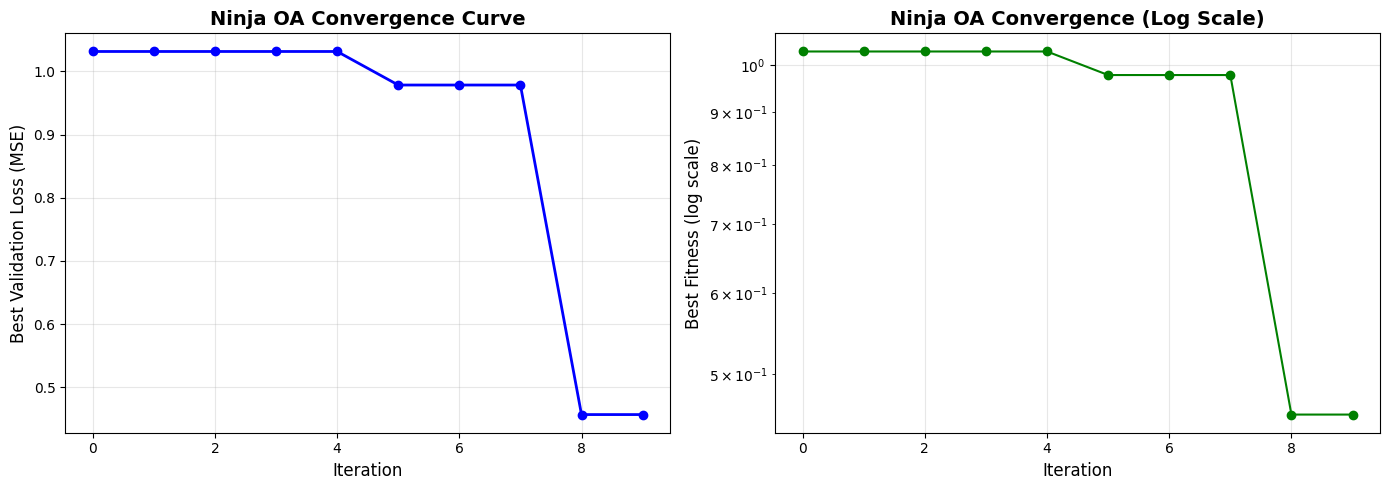


Convergence Statistics:
Starting fitness: 1.031473
Final fitness: 0.456892
Improvement: 55.70%


In [ ]:
# CELL 12: Visualize Convergence
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(convergence, 'b-o', linewidth=2, markersize=6)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Best Validation Loss (MSE)', fontsize=12)
plt.title('Ninja OA Convergence Curve', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(range(len(convergence)), convergence, 'go-', markersize=6)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Best Fitness (log scale)', fontsize=12)
plt.yscale('log')
plt.title('Ninja OA Convergence (Log Scale)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nConvergence Statistics:")
print(f"Starting fitness: {convergence[0]:.6f}")
print(f"Final fitness: {convergence[-1]:.6f}")
improvement = ((convergence[0] - convergence[-1]) / convergence[0] * 100)
print(f"Improvement: {improvement:.2f}%")


In [ ]:
# CELL 13: Train Final Model
print("Building final model with NiOA-optimized hyperparameters:\n")
for key, value in best_params.items():
    print(f"{key}: {value}")

final_model = create_lstm_model(best_params, seq_len, num_feats)
final_model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=7, min_lr=1e-6)

print("\nTraining final model...")
history = final_model.fit(
    X_train_seq, y_train_seq,
    epochs=200,
    batch_size=best_params['batch_size'],
    validation_data=(X_val_seq, y_val_seq),
    callbacks=[early_stop, reduce_lr],
    verbose=1
)


Building final model with NiOA-optimized hyperparameters:

lstm_layers: 3
units: 128
dropout: 0.5245520264652982
optimizer: adamw
learning_rate: 0.00016714717817375982
batch_size: 32


Model: "LSTM_NiOA"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 10, 256)        │       158,720 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 10, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 10, 128)        │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         1,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 497,843 (1.90 MB)

 Trainable params: 497,587 (1.90 MB)

 Non-trainable params: 256 (1.00 KB)


Training final model...
Epoch 1/200
1624/1624 ━━━━━━━━━━━━━━━━━━━━ 29s 14ms/step - loss: 0.6621 - mae: 0.6723 - val_loss: 1.4975 - val_mae: 1.2127 - learning_rate: 1.6715e-04
Epoch 2/200
1624/1624 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 0.4908 - mae: 0.6013 - val_loss: 1.6919 - val_mae: 1.2933 - learning_rate: 1.6715e-04
Epoch 3/200
1624/1624 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 0.4804 - mae: 0.5947 - val_loss: 1.8308 - val_mae: 1.3446 - learning_rate: 1.6715e-04
Epoch 4/200
1624/1624 ━━━━━━━━━━━━━━━━━━━━ 41s 13ms/step - loss: 0.4755 - mae: 0.5914 - val_loss: 1.7847 - val_mae: 1.3261 - learning_rate: 1.6715e-04
Epoch 5/200
1624/1624 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 0.4751 - mae: 0.5914 - val_loss: 1.8550 - val_mae: 1.3553 - learning_rate: 1.6715e-04
Epoch 6/200
1624/1624 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - loss: 0.4739 - mae: 0.5905 - val_loss: 1.7517 - val_mae: 1.3129 - learning_rate: 1.6715e-04
Epoch 7/200
1624/1624 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step - loss: 0.47


Evaluating final model...

FINAL RESULTS:
Validation MAE: 1.2128 | RMSE: 1.2237
Test MAE: 1.7302 | RMSE: 1.7357


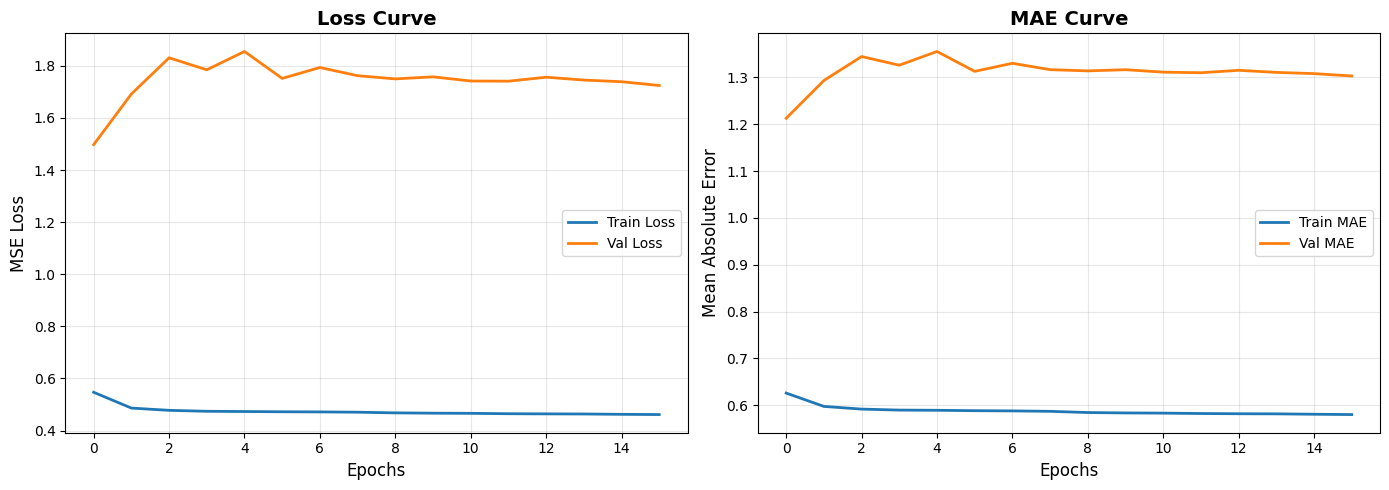

In [ ]:
# CELL 14: Evaluate Model
print("\nEvaluating final model...")

y_val_pred = final_model.predict(X_val_seq, verbose=0)
y_test_pred = final_model.predict(X_test_seq, verbose=0)

val_mae = mean_absolute_error(y_val_seq, y_val_pred)
val_rmse = np.sqrt(mean_squared_error(y_val_seq, y_val_pred))
test_mae = mean_absolute_error(y_test_seq, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test_seq, y_test_pred))

print(f"\nFINAL RESULTS:")
print(f"Validation MAE: {val_mae:.4f} | RMSE: {val_rmse:.4f}")
print(f"Test MAE: {test_mae:.4f} | RMSE: {test_rmse:.4f}")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('MSE Loss', fontsize=12)
plt.title('Loss Curve', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE', linewidth=2)
plt.plot(history.history['val_mae'], label='Val MAE', linewidth=2)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Absolute Error', fontsize=12)
plt.title('MAE Curve', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Computing comprehensive performance metrics...

COMPREHENSIVE MODEL EVALUATION

Validation Set Metrics:
  MAE: 1.2128
  RMSE: 1.2237
  R² Score: -65.5993
  MAPE: 127.46%
  Median AE: 1.1971
  Mean Error (Bias): 1.2128
  Std Error: 0.1636

Test Set Metrics:
  MAE: 1.7302
  RMSE: 1.7357
  R² Score: -133.2703
  MAPE: 117.63%
  Median AE: 1.7208
  Mean Error (Bias): 1.7302
  Std Error: 0.1386



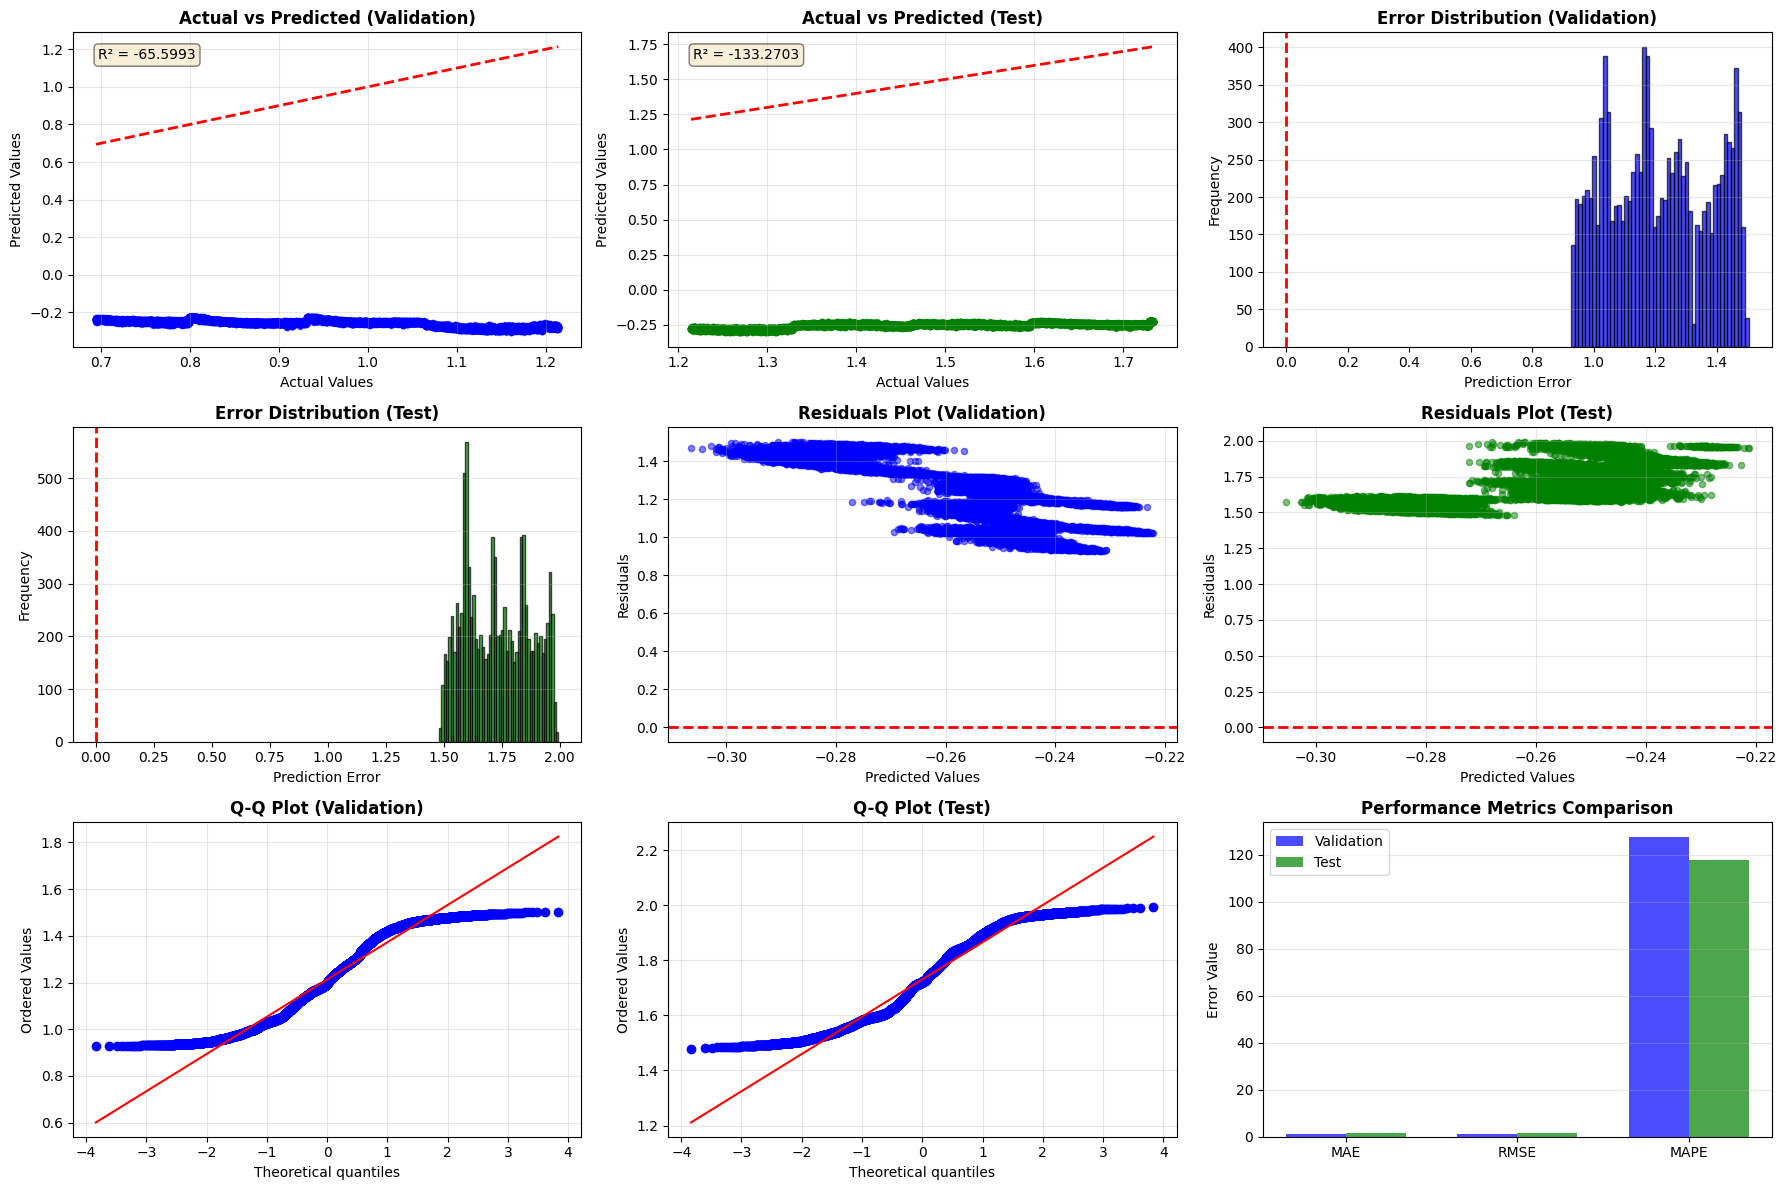


Model Performance Interpretation:
----------------------------------------------------------------------
Needs improvement: R² < 0.50
Excellent accuracy: MAPE < 5%
Model shows some bias
----------------------------------------------------------------------


In [ ]:
# CELL 15: Comprehensive Metrics
from sklearn.metrics import r2_score, mean_absolute_percentage_error

print("Computing comprehensive performance metrics...\n")

val_r2 = r2_score(y_val_seq, y_val_pred)
test_r2 = r2_score(y_test_seq, y_test_pred)

val_mape = mean_absolute_percentage_error(y_val_seq, y_val_pred)
test_mape = mean_absolute_percentage_error(y_test_seq, y_test_pred)

val_median_ae = np.median(np.abs(y_val_seq - y_val_pred.flatten()))
test_median_ae = np.median(np.abs(y_test_seq - y_test_pred.flatten()))

val_errors = y_val_seq - y_val_pred.flatten()
test_errors = y_test_seq - y_test_pred.flatten()

val_std_error = np.std(val_errors)
test_std_error = np.std(test_errors)

val_mean_error = np.mean(val_errors)
test_mean_error = np.mean(test_errors)

print("COMPREHENSIVE MODEL EVALUATION")
print("="*70)

print("\nValidation Set Metrics:")
print(f"  MAE: {val_mae:.4f}")
print(f"  RMSE: {val_rmse:.4f}")
print(f"  R² Score: {val_r2:.4f}")
print(f"  MAPE: {val_mape*100:.2f}%")
print(f"  Median AE: {val_median_ae:.4f}")
print(f"  Mean Error (Bias): {val_mean_error:.4f}")
print(f"  Std Error: {val_std_error:.4f}")

print("\nTest Set Metrics:")
print(f"  MAE: {test_mae:.4f}")
print(f"  RMSE: {test_rmse:.4f}")
print(f"  R² Score: {test_r2:.4f}")
print(f"  MAPE: {test_mape*100:.2f}%")
print(f"  Median AE: {test_median_ae:.4f}")
print(f"  Mean Error (Bias): {test_mean_error:.4f}")
print(f"  Std Error: {test_std_error:.4f}")

print("\n" + "="*70)

# Visualizations
fig = plt.figure(figsize=(18, 12))

ax1 = plt.subplot(3, 3, 1)
ax1.scatter(y_val_seq, y_val_pred, alpha=0.5, s=20, color='blue')
ax1.plot([y_val_seq.min(), y_val_seq.max()], [y_val_seq.min(), y_val_seq.max()], 'r--', lw=2)
ax1.set_xlabel('Actual Values')
ax1.set_ylabel('Predicted Values')
ax1.set_title('Actual vs Predicted (Validation)', fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.text(0.05, 0.95, f"R² = {val_r2:.4f}", transform=ax1.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax2 = plt.subplot(3, 3, 2)
ax2.scatter(y_test_seq, y_test_pred, alpha=0.5, s=20, color='green')
ax2.plot([y_test_seq.min(), y_test_seq.max()], [y_test_seq.min(), y_test_seq.max()], 'r--', lw=2)
ax2.set_xlabel('Actual Values')
ax2.set_ylabel('Predicted Values')
ax2.set_title('Actual vs Predicted (Test)', fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.text(0.05, 0.95, f"R² = {test_r2:.4f}", transform=ax2.transAxes, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax3 = plt.subplot(3, 3, 3)
ax3.hist(val_errors, bins=50, color='blue', alpha=0.7, edgecolor='black')
ax3.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax3.set_xlabel('Prediction Error')
ax3.set_ylabel('Frequency')
ax3.set_title('Error Distribution (Validation)', fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')

ax4 = plt.subplot(3, 3, 4)
ax4.hist(test_errors, bins=50, color='green', alpha=0.7, edgecolor='black')
ax4.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax4.set_xlabel('Prediction Error')
ax4.set_ylabel('Frequency')
ax4.set_title('Error Distribution (Test)', fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

ax5 = plt.subplot(3, 3, 5)
ax5.scatter(y_val_pred, val_errors, alpha=0.5, s=20, color='blue')
ax5.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax5.set_xlabel('Predicted Values')
ax5.set_ylabel('Residuals')
ax5.set_title('Residuals Plot (Validation)', fontweight='bold')
ax5.grid(True, alpha=0.3)

ax6 = plt.subplot(3, 3, 6)
ax6.scatter(y_test_pred, test_errors, alpha=0.5, s=20, color='green')
ax6.axhline(y=0, color='red', linestyle='--', linewidth=2)
ax6.set_xlabel('Predicted Values')
ax6.set_ylabel('Residuals')
ax6.set_title('Residuals Plot (Test)', fontweight='bold')
ax6.grid(True, alpha=0.3)

from scipy import stats as sp_stats

ax7 = plt.subplot(3, 3, 7)
sp_stats.probplot(val_errors, dist="norm", plot=ax7)
ax7.set_title('Q-Q Plot (Validation)', fontweight='bold')
ax7.grid(True, alpha=0.3)

ax8 = plt.subplot(3, 3, 8)
sp_stats.probplot(test_errors, dist="norm", plot=ax8)
ax8.set_title('Q-Q Plot (Test)', fontweight='bold')
ax8.grid(True, alpha=0.3)

ax9 = plt.subplot(3, 3, 9)
metrics_names = ['MAE', 'RMSE', 'MAPE']
val_metrics = [val_mae, val_rmse, val_mape*100]
test_metrics = [test_mae, test_rmse, test_mape*100]

x = np.arange(len(metrics_names))
width = 0.35

ax9.bar(x - width/2, val_metrics, width, label='Validation', color='blue', alpha=0.7)
ax9.bar(x + width/2, test_metrics, width, label='Test', color='green', alpha=0.7)
ax9.set_ylabel('Error Value')
ax9.set_title('Performance Metrics Comparison', fontweight='bold')
ax9.set_xticks(x)
ax9.set_xticklabels(metrics_names)
ax9.legend()
ax9.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nModel Performance Interpretation:")
print("-"*70)

if val_r2 > 0.85:
    print("Excellent model: R² > 0.85")
elif val_r2 > 0.70:
    print("Good model: R² > 0.70")
elif val_r2 > 0.50:
    print("Fair model: R² > 0.50")
else:
    print("Needs improvement: R² < 0.50")

if abs(val_mape) < 5:
    print("Excellent accuracy: MAPE < 5%")
elif abs(val_mape) < 10:
    print("Good accuracy: MAPE < 10%")
elif abs(val_mape) < 20:
    print("Fair accuracy: MAPE < 20%")

if abs(val_mean_error) < 0.1 * val_mae:
    print("Model is unbiased")
else:
    print("Model shows some bias")

print("-"*70)
